In [1]:
import numpy as np
import pandas as pd
import seaborn as brn
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [2]:
#read the data set and print the first rows

df=pd.read_csv('predictive_maintenance.csv')
df.head(4)

,Type,Air temperature,Process temperature,Rotational speed,Torque,Tool wear,Machine failure,TWF,HDF,PWF,OSF,RNF
0,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0


In [3]:
df.tail()

,Type,Air temperature,Process temperature,Rotational speed,Torque,Tool wear,Machine failure,TWF,HDF,PWF,OSF,RNF
9995,M,298.8,308.4,1604,29.5,14,0,0,0,0,0,0
9996,H,298.9,308.4,1632,31.8,17,0,0,0,0,0,0
9997,M,299.0,308.6,1645,33.4,22,0,0,0,0,0,0
9998,H,299.0,308.7,1408,48.5,25,0,0,0,0,0,0
9999,M,299.0,308.7,1500,40.2,30,0,0,0,0,0,0


In [4]:
# filtered to see how many rows had machine failure
# 339 rows have machine failure

df[df['Machine failure']==1]

,Type,Air temperature,Process temperature,Rotational speed,Torque,Tool wear,Machine failure,TWF,HDF,PWF,OSF,RNF
50,L,298.9,309.1,2861,4.6,143,1,0,0,1,0,0
69,L,298.9,309.0,1410,65.7,191,1,0,0,1,1,0
77,L,298.8,308.9,1455,41.3,208,1,1,0,0,0,0
160,L,298.4,308.2,1282,60.7,216,1,0,0,0,1,0
161,L,298.3,308.1,1412,52.3,218,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
9758,L,298.6,309.8,2271,16.2,218,1,1,0,0,0,0
9764,L,298.5,309.5,1294,66.7,12,1,0,0,1,0,0
9822,L,298.5,309.4,1360,60.9,187,1,0,0,0,1,0
9830,L,298.3,309.3,1337,56.1,206,1,0,0,0,1,0


In [5]:
df.shape
# (10000,12)

(10000, 12)

In [6]:
#print all column names 
print(df.columns)

Index(['Type', 'Air temperature', 'Process temperature', 'Rotational speed',
       'Torque', 'Tool wear', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF',
       'RNF'],
      dtype='object')


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Type                 10000 non-null  object 
 1   Air temperature      10000 non-null  float64
 2   Process temperature  10000 non-null  float64
 3   Rotational speed     10000 non-null  int64  
 4   Torque               10000 non-null  float64
 5   Tool wear            10000 non-null  int64  
 6   Machine failure      10000 non-null  int64  
 7   TWF                  10000 non-null  int64  
 8   HDF                  10000 non-null  int64  
 9   PWF                  10000 non-null  int64  
 10  OSF                  10000 non-null  int64  
 11  RNF                  10000 non-null  int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 937.6+ KB


In [8]:
# statistical summary of the data
df.describe()

,Air temperature,Process temperature,Rotational speed,Torque,Tool wear,Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


In [9]:
# checking for null values
df.isnull().sum()

Type                   0
Air temperature        0
Process temperature    0
Rotational speed       0
Torque                 0
Tool wear              0
Machine failure        0
TWF                    0
HDF                    0
PWF                    0
OSF                    0
RNF                    0
dtype: int64

In [10]:
# check for dupicates
df.duplicated().sum()

np.int64(0)

In [11]:
df=df.rename(columns={'Type':'Satellite Type','Air temperature':'Internal Tenperature(°C)',
                  'Process temperature':'Payload Temperature (°C)',
                  'Rotational speed':'Reaction Wheel Speed(RPM)',
                  'Torque':'Reaction Wheel Torque(Nm)',
                  'Tool wear':'Component OPerating Hours',              
                  'Machine failure':'Satellite Failure',
                  'TWF':'Solar Panel Failure',                    
                  'HDF':'Thermal Control Failure',                    
                  'PWF':'Power System Failure',
                  'OSF':'Attitude Control Failure',
                  'RNF':'Communication System Failure'})
                  

In [12]:
df.columns

Index(['Satellite Type', 'Internal Tenperature(°C)',
       'Payload Temperature (°C)', 'Reaction Wheel Speed(RPM)',
       'Reaction Wheel Torque(Nm)', 'Component OPerating Hours',
       'Satellite Failure', 'Solar Panel Failure', 'Thermal Control Failure',
       'Power System Failure', 'Attitude Control Failure',
       'Communication System Failure'],
      dtype='object')

In [13]:
# assinig columns to x and y for training and testing

x=df[['Satellite Type', 'Internal Tenperature(°C)',
       'Payload Temperature (°C)', 'Reaction Wheel Speed(RPM)',
       'Reaction Wheel Torque(Nm)', 'Component OPerating Hours']]

In [14]:
y=df['Satellite Failure']

In [15]:
# converting string type column into int for machine learning

from sklearn.preprocessing import LabelEncoder
encoder=LabelEncoder()
x['Satellite Type']=encoder.fit_transform(x['Satellite Type'])

C:\Users\ASUS\AppData\Local\Temp\ipykernel_7576\3700523988.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x['Satellite Type']=encoder.fit_transform(x['Satellite Type'])


In [16]:
x.dtypes

Satellite Type                 int64
Internal Tenperature(°C)     float64
Payload Temperature (°C)     float64
Reaction Wheel Speed(RPM)      int64
Reaction Wheel Torque(Nm)    float64
Component OPerating Hours      int64
dtype: object

In [17]:
# train test split

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.20,random_state=42,stratify=y)

In [18]:
# checking train test split
print(x_train.shape)
print(x_test.shape)

print(y_train.value_counts())
print(y_test.value_counts())

(8000, 6)
(2000, 6)
Satellite Failure
0    7729
1     271
Name: count, dtype: int64
Satellite Failure
0    1932
1      68
Name: count, dtype: int64


In [19]:
# normalizing the numerial data for training making mean 0 and standard deviation 1

# scaler = StandardScaler()

# numeric_column=['Internal Tenperature(°C)',
# 'Payload Temperature (°C)',
# 'Reaction Wheel Speed(RPM)',      
# 'Reaction Wheel Torque(Nm)',    
# 'Component OPerating Hours']

# x_train[numeric_column]= scaler.fit_transform(x_train[numeric_column])
# x_test[numeric_column]= scaler.transform(x_test[numeric_column])

#EDA#

<function matplotlib.pyplot.show(close=None, block=None)>

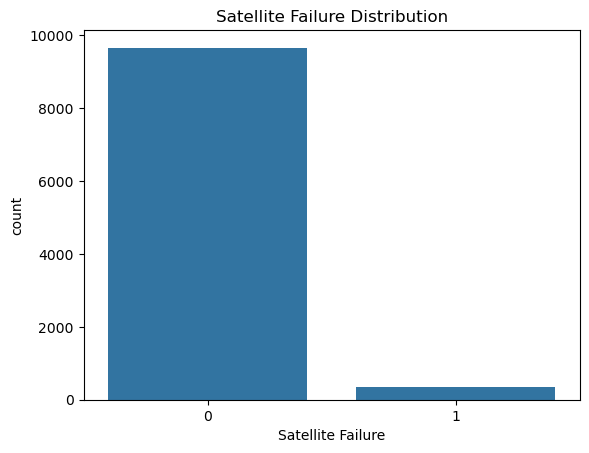

In [20]:
# TARGET DISTRIBUTION - my target is sattelite failure so it is simply that how many failure vs how many not 
# countplot -- that shows the number of occurences for each category in a specific variable 

brn.countplot(x='Satellite Failure',data=df)
plt.title('Satellite Failure Distribution')
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

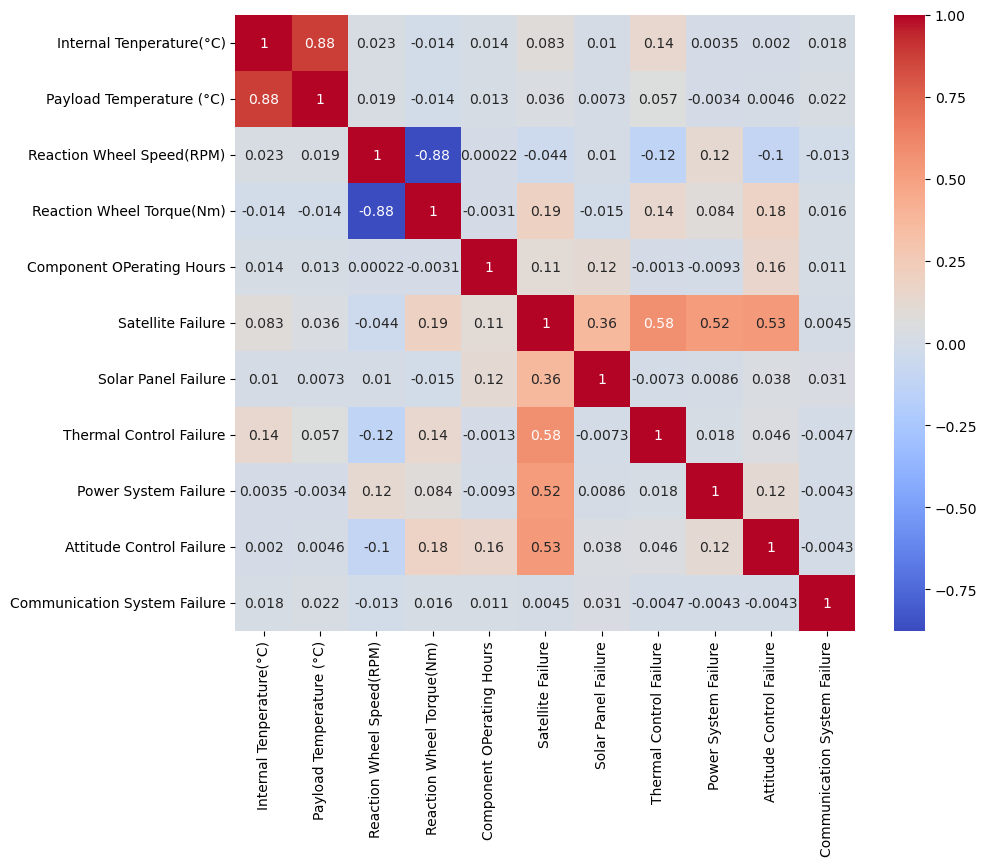

In [21]:
# corelation heatmap-- graph that shows how different data items relate to each other using colour 
# value close to 1 --positive link ie, one item goes up other one also go up(red)
# value close to -1 -- negative link(blue)
# value close to 0 -- no link
plt.figure(figsize=(10,8))

brn.heatmap(df.corr(numeric_only=True),annot=True,cmap='coolwarm')
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

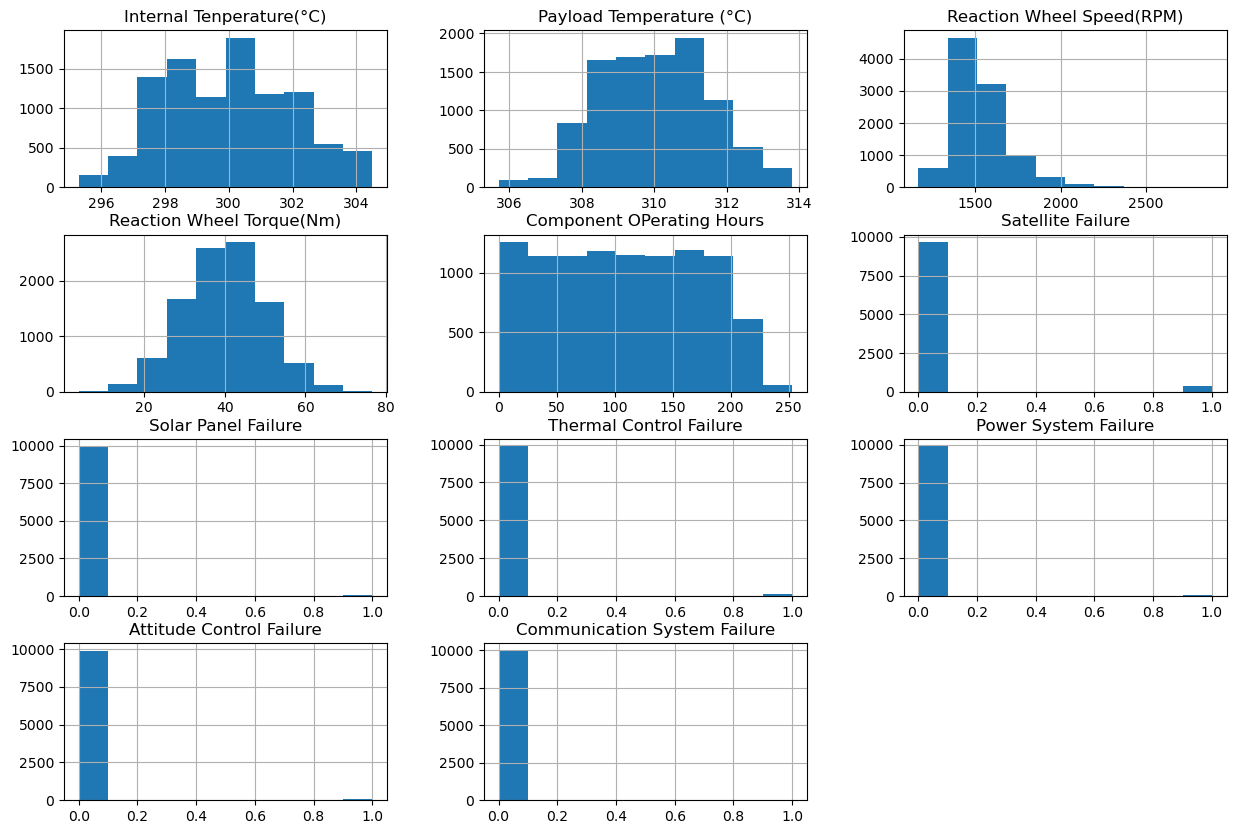

In [22]:
# DISTRIBUTION OF NUMERIC FEATURES --- frequency and pattern of the data 
# (normal , uniform , skewed)
# using histogram-- shows numeric distribution by grouping contineous data into intervals
df.hist(figsize=(15,10))
plt.tight_layout
plt.show


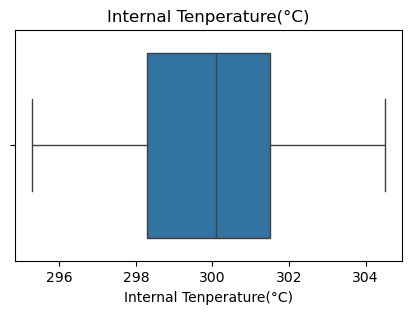

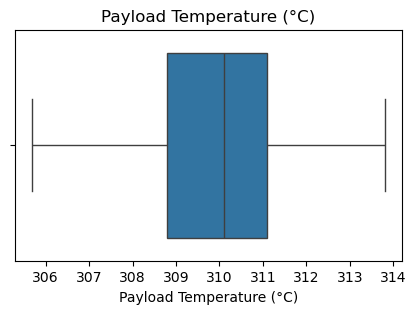

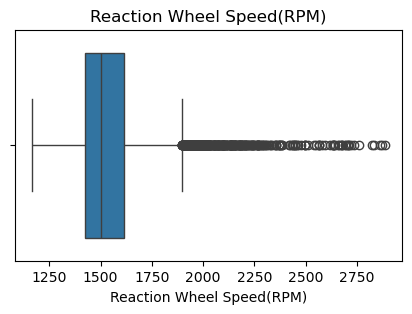

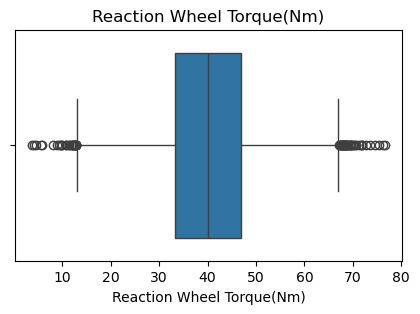

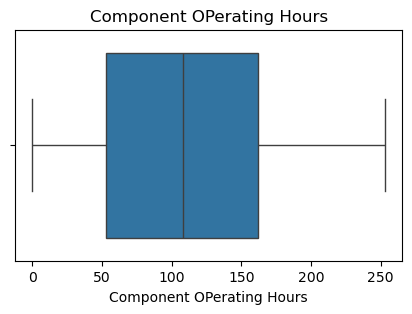

In [23]:
# OUTLIER DETECTION USING BOXPLOTS 
for col in ['Internal Tenperature(°C)',
'Payload Temperature (°C)',
'Reaction Wheel Speed(RPM)',      
'Reaction Wheel Torque(Nm)',    
'Component OPerating Hours']:
    plt.figure(figsize=(5,3))
    brn.boxplot(x=df[col])
    plt.title(col)
    plt.show()

In [24]:
# BEACAUSE OF OUTLIER IN RPM CHECKING THE REASON AND GOT THAT THERE MAYBE SATELLITE FAILURE WHEN RPM GO BEYOUD 2000

df[df['Reaction Wheel Speed(RPM)']>2000]["Satellite Failure"].value_counts()

Satellite Failure
0    193
1     33
Name: count, dtype: int64

In [25]:
# BECAUSE OF OUTLIER IN TORQUR CHECKING WITH SATELLITE FAILURE AND GOT THAT SATTELITE FAILURE MOSTLY HAPPEN THE OUTLIER VALUES 

df[df["Reaction Wheel Torque(Nm)"] > 65]["Satellite Failure"].value_counts()

df[df["Reaction Wheel Torque(Nm)"] < 15]["Satellite Failure"].value_counts()

Satellite Failure
1    30
0    27
Name: count, dtype: int64

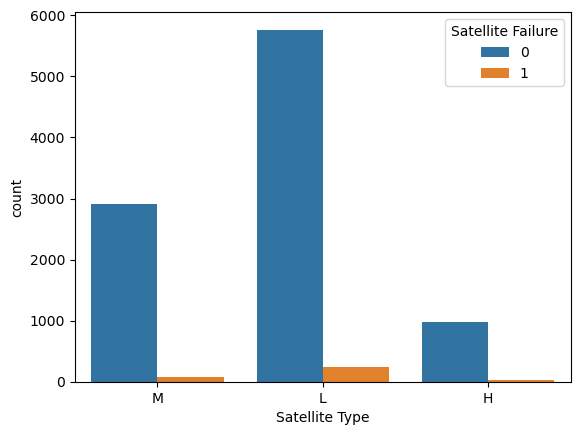

In [26]:
# FAILURE RATE BY SATELLITE TYPE
brn.countplot(x='Satellite Type',hue='Satellite Failure',data=df)
plt.show()

#BUILDING FIRST LOGISTIC MODEL#

In [27]:
from sklearn.linear_model import LogisticRegression

logi_model= LogisticRegression(class_weight='balanced',random_state=42)
logi_model.fit(x_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [28]:
# predictions
pred=logi_model.predict(x_test)
logi_model.predict(x_train)
# logi_model.predict([[1	,0.247681	,-0.139294	,-1.073963	,2.265378	,0.712410]])
# logi_model.predict([[1,	1.850310	,1.618248,	-0.145641,	0.009646,	0.429427]]) #xtest data
# logi_model.predict([[1	,0.247681	,-0.139294	,-1.073963	,2.265378	,0.712410]]) #xtrain data

array([0, 0, 0, ..., 0, 0, 0], shape=(8000,))

In [29]:
logi_model.score(x_train,y_train)

0.8205

In [30]:
# EVALUATING THE LOGI_MODEL

print("Accuracy:", accuracy_score(y_test,pred ))

print(confusion_matrix(y_test, pred))

print(classification_report(y_test, pred))

Accuracy: 0.8205
[[1585  347]
 [  12   56]]
              precision    recall  f1-score   support

           0       0.99      0.82      0.90      1932
           1       0.14      0.82      0.24        68

    accuracy                           0.82      2000
   macro avg       0.57      0.82      0.57      2000
weighted avg       0.96      0.82      0.88      2000



In [31]:
# RECALL 0.84 
# This is the most important metric.

# It means:

# Out of 68 actual failures, the model detected 57.

# Only 11 failures were missed.

# For predictive maintenance, missing a real failure can be much more costly than investigating a healthy satellite, so high recall is desirable.

# Precision = 0.14
# Precision = 0.14

# This is low.

# It means:

# When the model predicts "Failure," it is correct only 14% of the time.

# Many healthy satellites are being flagged unnecessarily (347 false alarms).

# F1-Score = 0.24

# This is also low because precision is low.

In [32]:
y_test[y_test==1]

4851    1
1391    1
4495    1
8582    1
9664    1
       ..
4661    1
1996    1
4034    1
4342    1
4727    1
Name: Satellite Failure, Length: 68, dtype: int64

#DECISION TREE MODEL#

In [33]:
from sklearn.tree import DecisionTreeClassifier

In [34]:
dt_model=DecisionTreeClassifier(class_weight='balanced',random_state=42)
dt_model.fit(x_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,'balanced'


In [35]:
# DECISION TREE MODEL PREDICTION
dt_predict=dt_model.predict(x_test)
dt_predict

array([0, 0, 0, ..., 0, 0, 0], shape=(2000,))

In [36]:
# EVALUATING THE DECISION TREE _MODEL

print("Accuracy:", accuracy_score(y_test,dt_predict ))

print(confusion_matrix(y_test, dt_predict))

print(classification_report(y_test, dt_predict))

Accuracy: 0.978
[[1915   17]
 [  27   41]]
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1932
           1       0.71      0.60      0.65        68

    accuracy                           0.98      2000
   macro avg       0.85      0.80      0.82      2000
weighted avg       0.98      0.98      0.98      2000



In [37]:
from sklearn.ensemble import RandomForestClassifier

In [38]:
rf_model = RandomForestClassifier(n_estimators=100,random_state=42,class_weight='balanced')
# | Parameter                  Meaning                        |
# | -------------------------  ------------------------------ |
# | `n_estimators=100`         Builds 100 decision trees      |
# | `random_state=42`          Ensures reproducible results   |
# | `class_weight='balanced'`  Handles the imbalanced dataset |

rf_model.fit(x_train, y_train)


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [39]:
rf_pred = rf_model.predict(x_test)
rf_pred

array([0, 0, 0, ..., 0, 0, 0], shape=(2000,))

In [40]:
# EVALUATING RANDOM FOREST MODEL
print("Accuracy:", accuracy_score(y_test, rf_pred))
print(confusion_matrix(y_test, rf_pred))
print(classification_report(y_test, rf_pred))

Accuracy: 0.9815
[[1928    4]
 [  33   35]]
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1932
           1       0.90      0.51      0.65        68

    accuracy                           0.98      2000
   macro avg       0.94      0.76      0.82      2000
weighted avg       0.98      0.98      0.98      2000



In [41]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=4,
    class_weight='balanced',
    random_state=42
)
rf_model.fit(x_train, y_train)
rf_pred = rf_model.predict(x_test)
rf_pred

array([1, 0, 0, ..., 0, 0, 0], shape=(2000,))

In [42]:
# modified random forest model evaluation

print("Accuracy:", accuracy_score(y_test, rf_pred))
print(confusion_matrix(y_test, rf_pred))
print(classification_report(y_test, rf_pred))

Accuracy: 0.974
[[1895   37]
 [  15   53]]
              precision    recall  f1-score   support

           0       0.99      0.98      0.99      1932
           1       0.59      0.78      0.67        68

    accuracy                           0.97      2000
   macro avg       0.79      0.88      0.83      2000
weighted avg       0.98      0.97      0.98      2000



                     Feature  Importance
4  Reaction Wheel Torque(Nm)    0.338362
3  Reaction Wheel Speed(RPM)    0.291920
5  Component OPerating Hours    0.210253
1   Internal Tenperature(°C)    0.091002
2   Payload Temperature (°C)    0.056901
0             Satellite Type    0.011562


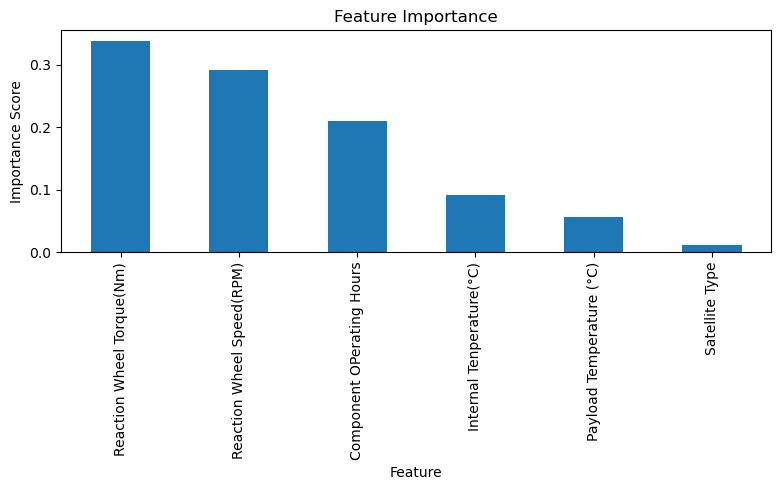

In [43]:


importance = pd.DataFrame({
    "Feature": x.columns,
    "Importance": rf_model.feature_importances_
})

importance = importance.sort_values(by="Importance", ascending=False)

print(importance)

importance.plot(
    x="Feature",
    y="Importance",
    kind="bar",
    legend=False,
    figsize=(8,5)
)

plt.title("Feature Importance")
plt.ylabel("Importance Score")
plt.tight_layout()
plt.show()

In [44]:
from sklearn.ensemble import GradientBoostingClassifier

In [45]:
gb_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)
# | Parameter           | Meaning                           |
# | ------------------- | --------------------------------- |
# | `n_estimators=100`  | Number of boosting stages (trees) |
# | `learning_rate=0.1` | Contribution of each tree         |
# | `max_depth=3`       | Maximum depth of each tree        |
# | `random_state=42`   | Reproducible results              |

gb_model.fit(x_train, y_train)

gb_pred = gb_model.predict(x_test)
gb_pred


array([0, 0, 0, ..., 0, 0, 0], shape=(2000,))

In [46]:
# gradient boosting evaluation

print("Accuracy:", accuracy_score(y_test, gb_pred))
print(confusion_matrix(y_test, gb_pred))
print(classification_report(y_test, gb_pred))

Accuracy: 0.985
[[1925    7]
 [  23   45]]
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1932
           1       0.87      0.66      0.75        68

    accuracy                           0.98      2000
   macro avg       0.93      0.83      0.87      2000
weighted avg       0.98      0.98      0.98      2000



In [47]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [48]:
from xgboost import XGBClassifier

In [49]:
negative = y_train.value_counts()[0]
positive = y_train.value_counts()[1]

scale_pos_weight = negative / positive

print(scale_pos_weight)

28.52029520295203


In [50]:
xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss'
)

# | Parameter          | Meaning                                 |
# | ------------------ | --------------------------------------- |
# | `n_estimators`     | Number of trees                         |
# | `learning_rate`    | Learning speed                          |
# | `max_depth`        | Maximum tree depth                      |
# | `subsample`        | Fraction of training rows used per tree |
# | `colsample_bytree` | Fraction of features used per tree      |
# | `scale_pos_weight` | Handles class imbalance                 |
# | `eval_metric`      | Evaluation metric during training       |

xgb_model.fit(x_train, y_train)

xgb_pred = xgb_model.predict(x_test)
xgb_pred


array([1, 0, 0, ..., 0, 0, 0], shape=(2000,))

In [51]:
# xgb evaluation

print("Accuracy:", accuracy_score(y_test, xgb_pred))
print(confusion_matrix(y_test, xgb_pred))
print(classification_report(y_test, xgb_pred))

Accuracy: 0.9565
[[1854   78]
 [   9   59]]
              precision    recall  f1-score   support

           0       1.00      0.96      0.98      1932
           1       0.43      0.87      0.58        68

    accuracy                           0.96      2000
   macro avg       0.71      0.91      0.78      2000
weighted avg       0.98      0.96      0.96      2000



In [52]:
print("Training Accuracy:", xgb_model.score(x_train, y_train))
print("Testing Accuracy:", xgb_model.score(x_test, y_test))

Training Accuracy: 0.9645
Testing Accuracy: 0.9565


In [53]:
# Save the model
import joblib

# Save the model
joblib.dump(xgb_model, "satellite maintanence_model.joblib")





FileNotFoundError: [Errno 2] No such file or directory: 'xgb_model.joblib'